# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

/kaggle/input/global-supply-chain-risk-and-logistics-2024-2026/global_supply_chain_risk_2026.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('global_supply_chain_risk_2026.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


## last Five row

In [4]:
df.tail()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
4995,SC-14995,2025-11-10,Rotterdam,Dubai,Rail,Perishables,13512.26,428.97,3.35,8.8,Fog,0.664,20.28,0
4996,SC-14996,2025-11-23,Dubai,Shanghai,Air,Perishables,2231.02,448.86,1.79,0.5,Clear,0.863,0.50,0
4997,SC-14997,2025-10-18,Antwerp,Busan,Rail,Pharmaceuticals,5253.72,473.41,1.37,3.0,Clear,0.962,4.41,0
4998,SC-14998,2025-01-29,Singapore,Dubai,Rail,Automotive,12328.31,199.35,3.45,4.4,Storm,0.819,31.18,1
4999,SC-14999,2024-06-01,Dubai,Shanghai,Air,Textiles,9161.03,109.35,2.03,1.7,Storm,0.976,1.43,1


## Shape of our dataset

In [5]:
df.shape

(5000, 14)

## List out all columns

In [6]:
df.columns

Index(['Shipment_ID', 'Date', 'Origin_Port', 'Destination_Port',
       'Transport_Mode', 'Product_Category', 'Distance_km', 'Weight_MT',
       'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Weather_Condition',
       'Carrier_Reliability_Score', 'Lead_Time_Days', 'Disruption_Occurred'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Shipment_ID                   object
Date                          object
Origin_Port                   object
Destination_Port              object
Transport_Mode                object
Product_Category              object
Distance_km                  float64
Weight_MT                    float64
Fuel_Price_Index             float64
Geopolitical_Risk_Score      float64
Weather_Condition             object
Carrier_Reliability_Score    float64
Lead_Time_Days               float64
Disruption_Occurred            int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   object 
 1   Date                       5000 non-null   object 
 2   Origin_Port                5000 non-null   object 
 3   Destination_Port           5000 non-null   object 
 4   Transport_Mode             5000 non-null   object 
 5   Product_Category           5000 non-null   object 
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   object 
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-null   int64

## Check Null Value

In [9]:
df.isnull().sum()

Shipment_ID                  0
Date                         0
Origin_Port                  0
Destination_Port             0
Transport_Mode               0
Product_Category             0
Distance_km                  0
Weight_MT                    0
Fuel_Price_Index             0
Geopolitical_Risk_Score      0
Weather_Condition            0
Carrier_Reliability_Score    0
Lead_Time_Days               0
Disruption_Occurred          0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7704.063888,246.252052,2.854552,5.076900,0.754387,19.355386,0.612600
std,4199.687885,142.522591,0.959533,2.877832,0.144363,31.405143,0.487205
min,500.170000,1.030000,1.200000,0.000000,0.500000,0.500000,0.000000
25%,4036.010000,124.330000,2.020000,2.600000,0.629000,2.110000,0.000000
50%,7750.125000,243.500000,2.840000,5.100000,0.757000,8.245000,1.000000
75%,11347.462500,366.955000,3.710000,7.500000,0.879000,21.207500,1.000000
max,14995.910000,499.750000,4.500000,10.000000,1.000000,236.390000,1.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

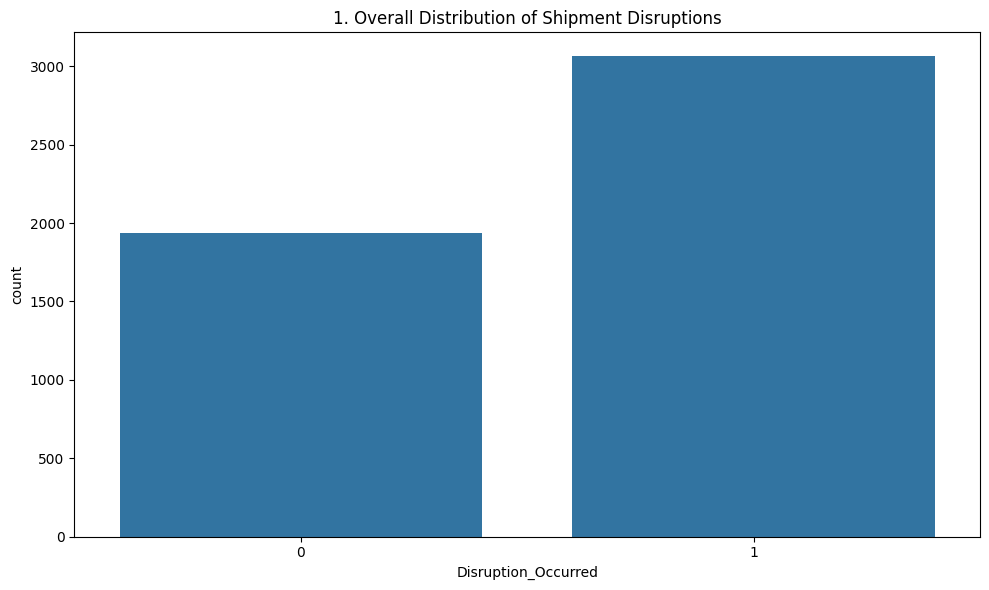

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Disruption_Occurred')
plt.title(f'{plot_no}. Overall Distribution of Shipment Disruptions')
show_fig()
plot_no += 1

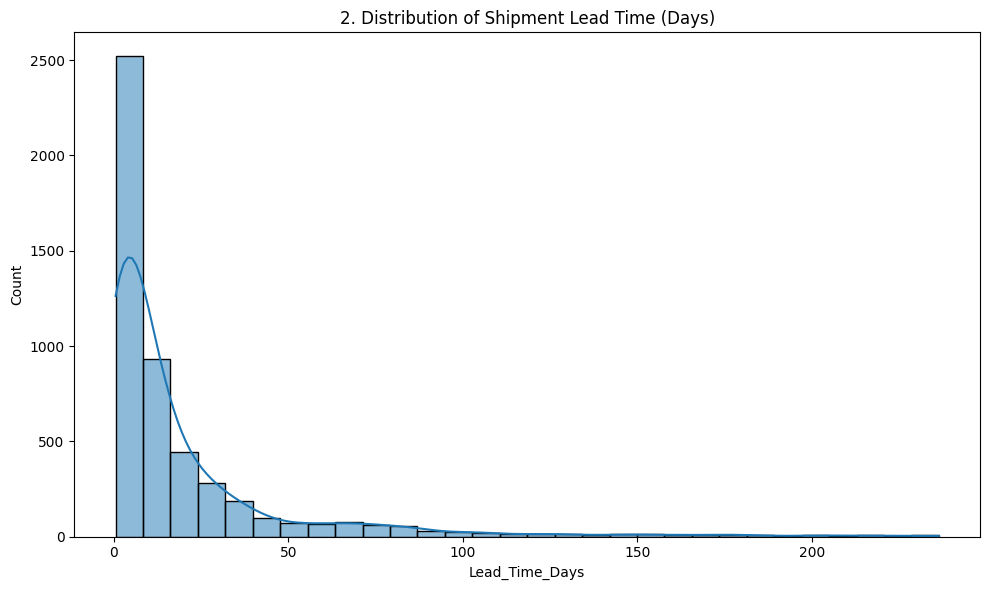

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Lead_Time_Days'], kde=True, bins=30)
plt.title(f'{plot_no}. Distribution of Shipment Lead Time (Days)')
show_fig()
plot_no += 1

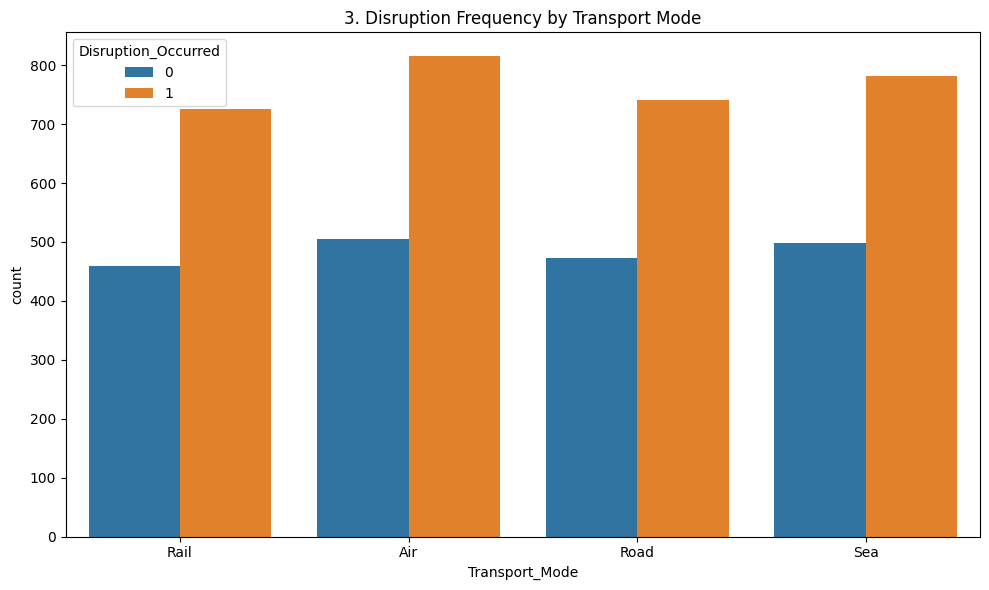

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Transport_Mode', hue='Disruption_Occurred')
plt.title(f'{plot_no}. Disruption Frequency by Transport Mode')
show_fig()
plot_no += 1

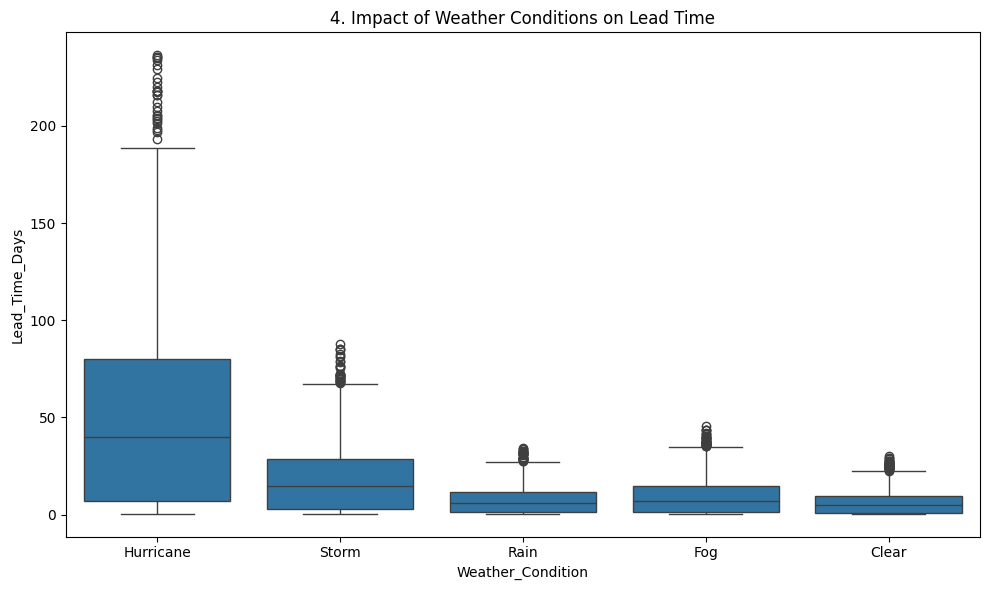

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Weather_Condition', y='Lead_Time_Days')
plt.title(f'{plot_no}. Impact of Weather Conditions on Lead Time')
show_fig()
plot_no += 1

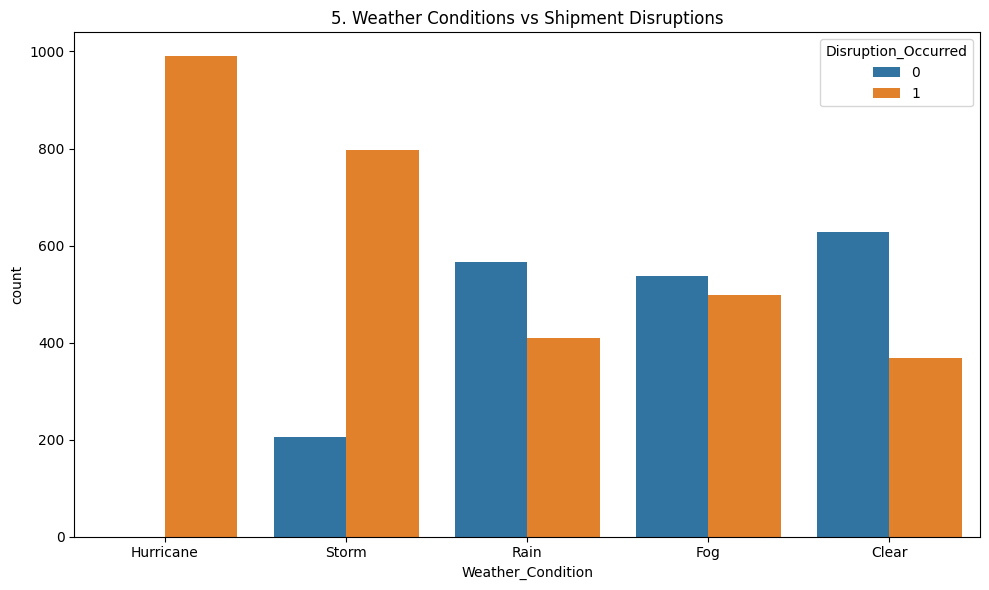

In [17]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Weather_Condition', hue='Disruption_Occurred')
plt.title(f'{plot_no}. Weather Conditions vs Shipment Disruptions')
show_fig()
plot_no += 1

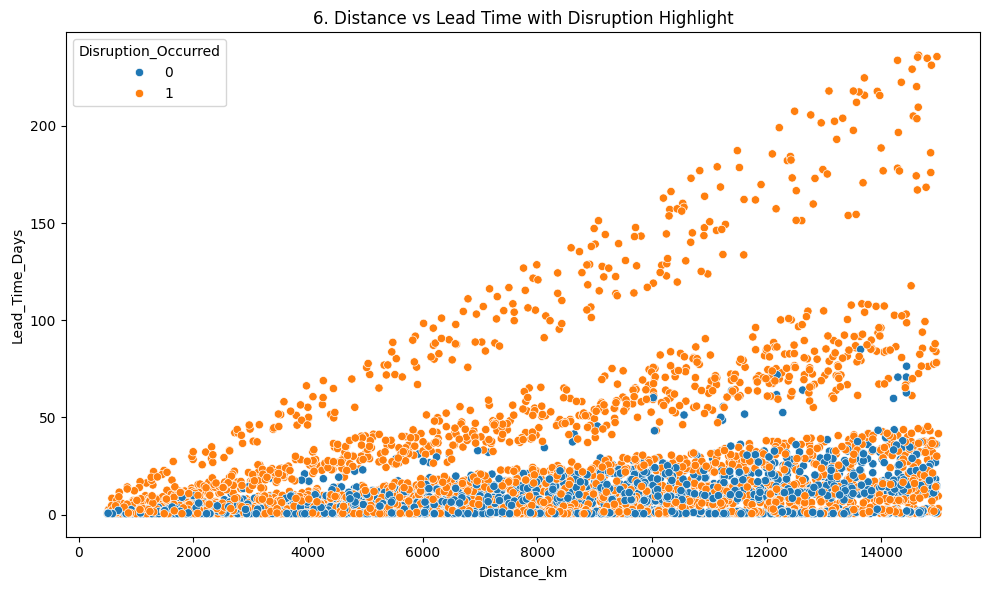

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Distance_km', y='Lead_Time_Days', hue='Disruption_Occurred')
plt.title(f'{plot_no}. Distance vs Lead Time with Disruption Highlight')
show_fig()
plot_no += 1

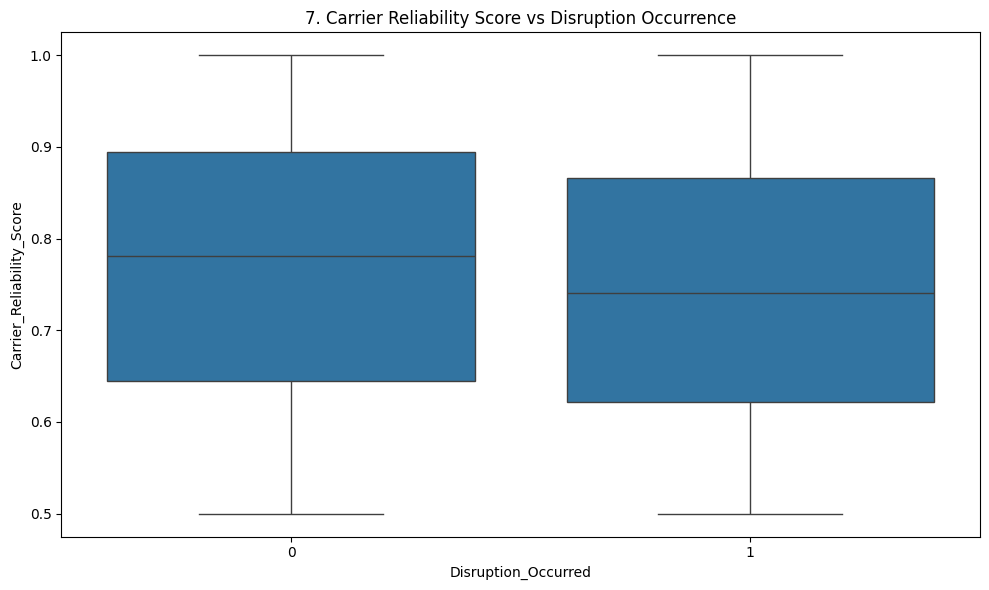

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Disruption_Occurred', y='Carrier_Reliability_Score')
plt.title(f'{plot_no}. Carrier Reliability Score vs Disruption Occurrence')
show_fig()
plot_no += 1

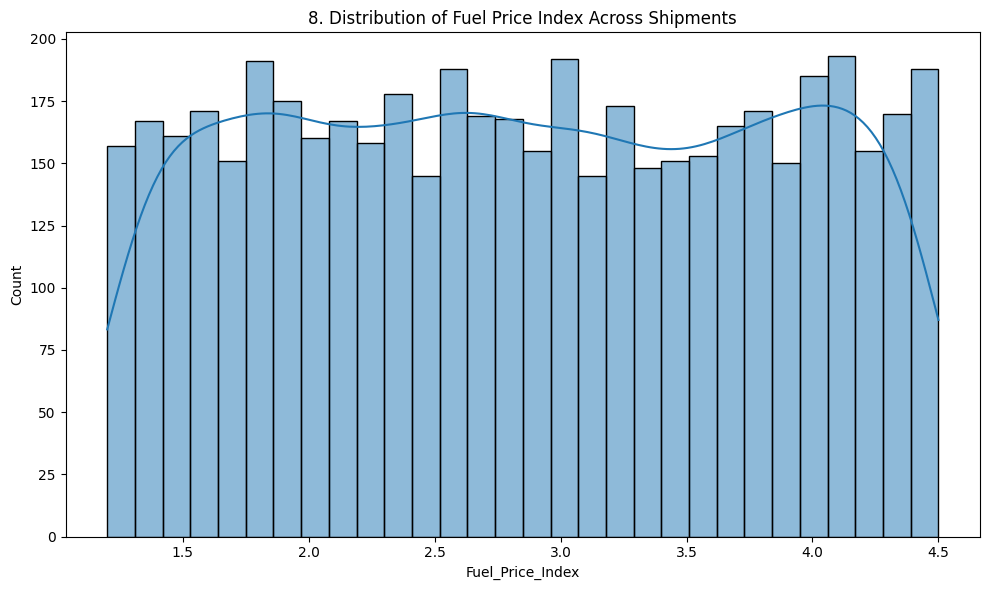

In [20]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Fuel_Price_Index'], kde=True, bins=30)
plt.title(f'{plot_no}. Distribution of Fuel Price Index Across Shipments')
show_fig()
plot_no += 1

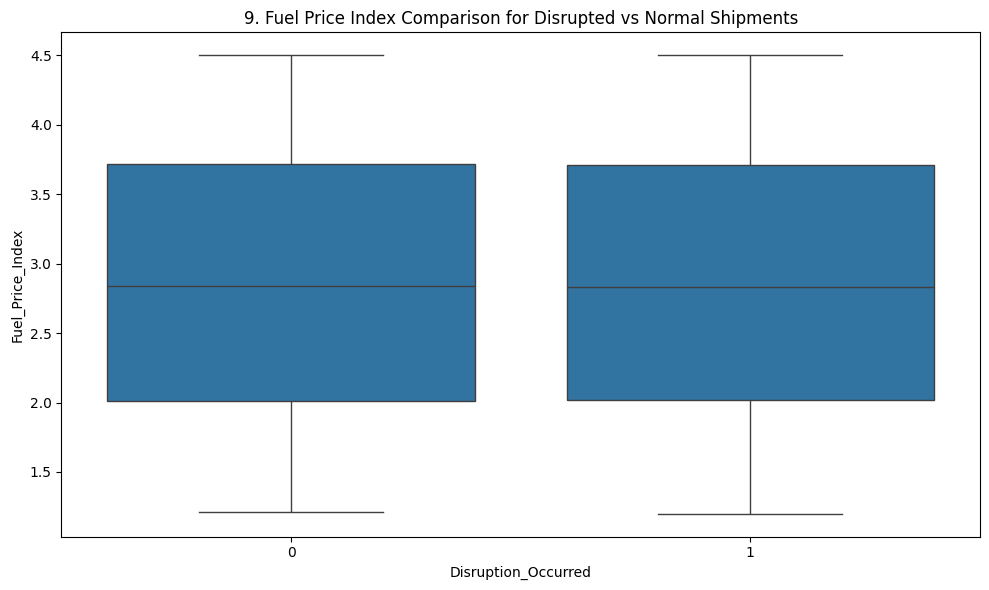

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Disruption_Occurred', y='Fuel_Price_Index')
plt.title(f'{plot_no}. Fuel Price Index Comparison for Disrupted vs Normal Shipments')
show_fig()
plot_no += 1

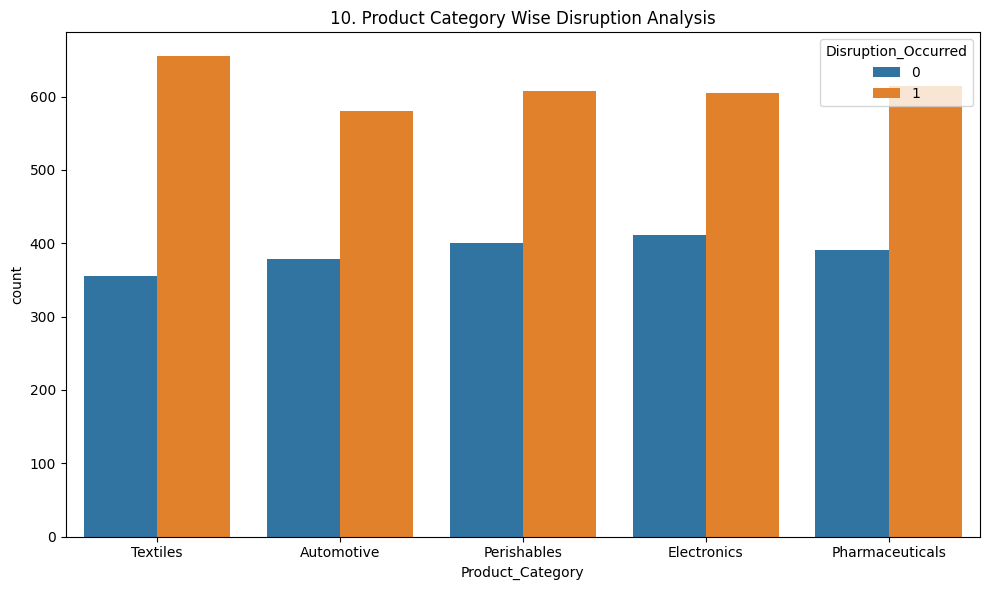

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Product_Category', hue='Disruption_Occurred')
plt.title(f'{plot_no}. Product Category Wise Disruption Analysis')
show_fig()
plot_no += 1

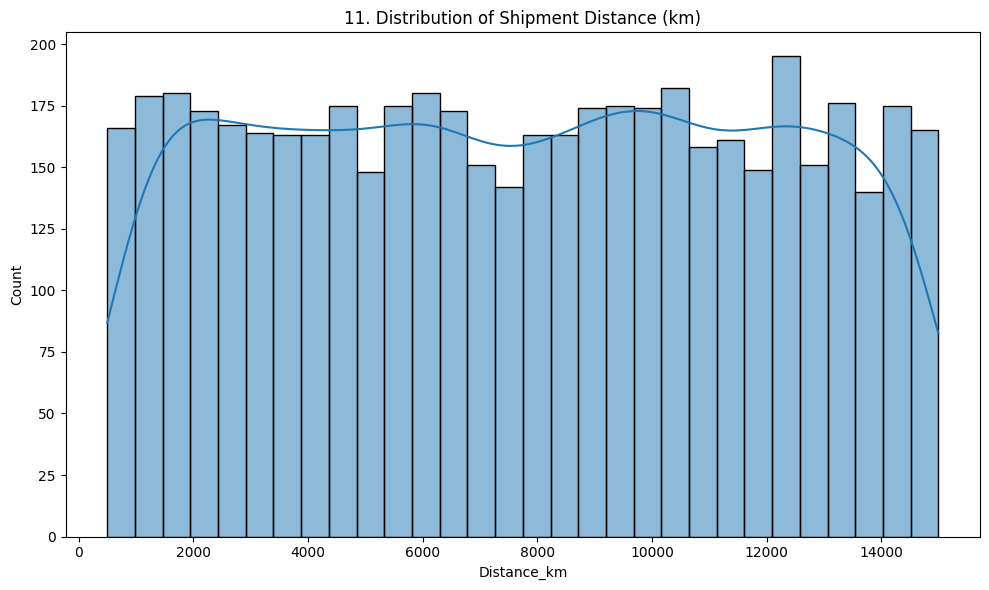

In [23]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Distance_km'], kde=True, bins=30)
plt.title(f'{plot_no}. Distribution of Shipment Distance (km)')
show_fig()
plot_no += 1

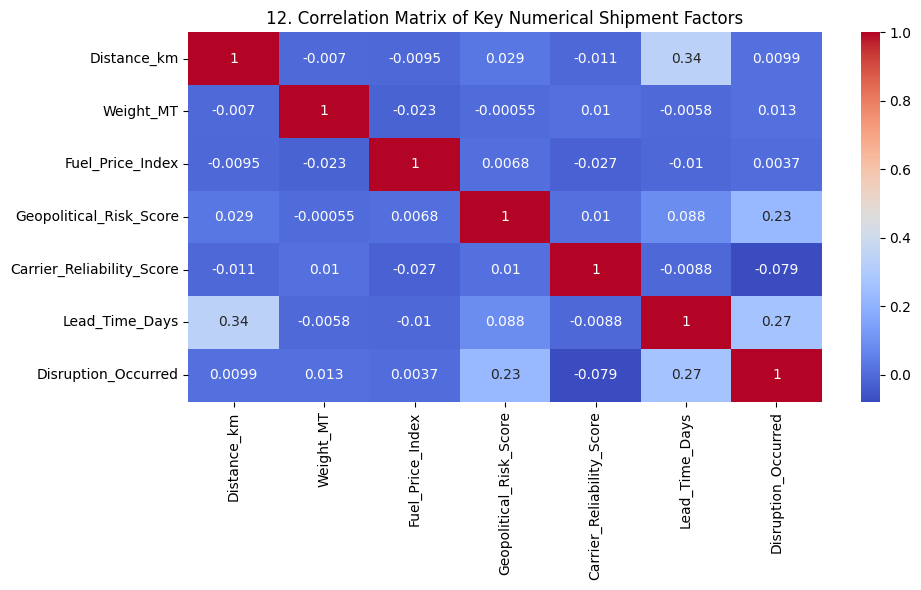

In [24]:
fig = plt.figure(figsize=(10,6))
corr = df[['Distance_km','Weight_MT','Fuel_Price_Index','Geopolitical_Risk_Score','Carrier_Reliability_Score','Lead_Time_Days','Disruption_Occurred']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Matrix of Key Numerical Shipment Factors')
show_fig()
plot_no += 1

# Model Training

## Select numerical features and target

In [25]:
X = df[['Distance_km','Weight_MT','Fuel_Price_Index','Geopolitical_Risk_Score',
        'Carrier_Reliability_Score','Lead_Time_Days']]
y = df['Disruption_Occurred']

## Split dataset into training and testing sets

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

## Scale features for better model performance

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Train Logistic Regression model

In [28]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

## Make predictions

In [29]:
y_pred = model.predict(X_test_scaled)

## Print model accuracy

In [30]:
print("Model Accuracy:", accuracy_score(y_test, y_pred))

Model Accuracy: 0.6704


## Plot confusion matrix

<Figure size 800x600 with 0 Axes>

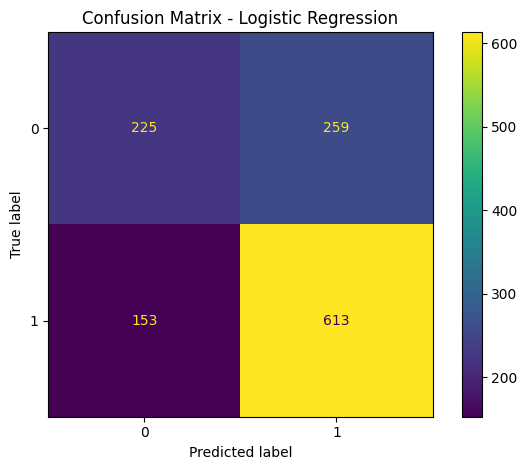

In [31]:
fig = plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()